# MTH739 – Topics in Scientific Computing 2025/26
# Coursework 1 : Trisolaris: the three body problem

### Setup

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

G = 1.0

# SIMPLE STAR CLASS

class Star:
    
    # Represents a star with mass m, position x,y and velocity vx, vy

    def __init__(self, mass, x, y, vx, vy):
        # Defensive checks
        """ Took help from GenAI, Stackoverflow, Reddit to write the assertions here """
        
        assert isinstance(mass, (int, float)),  "mass must be numeric"
        assert mass > 0, "mass must be > 0"
        for v in (x, y, vx, vy):
            assert isinstance(v, (int, float)), "positions and velocities must be numeric"
            assert np.isfinite(v),              "positions/velocities must be finite numbers"
            
        self.mass = mass
        self.x = x
        self.y = y
        self.vx = vx
        self.vy = vy


# STAR SYSTEM CLASS

class StarSystem:
    
    # Represents a system of stars

    def __init__(self, stars):
        assert isinstance(stars, list) and len(stars) >= 1, "stars must be a non-empty list"
        for s in stars:
            assert isinstance(s, Star), "each element must be a Star"
        self.stars = stars
        self.N = len(stars)


    # Calculate accelerations

    def compute_accelerations(self):
        
    # Returns arrays ax, ay of accelerations for each star due to all others

        N = len(self.stars)
        ax = np.zeros(N)
        ay = np.zeros(N)

        N = self.N
        ax = np.zeros(N, dtype=float)
        ay = np.zeros(N, dtype=float)
        for i in range(N):
            xi, yi = self.stars[i].x, self.stars[i].y
            for j in range(N):
                if j == i:
                    continue
                xj, yj = self.stars[j].x, self.stars[j].y

                dx = xj - xi
                dy = yj - yi

                r2 = dx*dx + dy*dy
                # protection against r==0
                if r2 == 0.0:
                    r2 = 1e-12
                r = np.sqrt(r2)

                a_mag = self.stars[j].mass / r2   # G assumed 1
                ax[i] += a_mag * (dx / r)
                ay[i] += a_mag * (dy / r)
        return ax, ay


    # RHS FOR solve_ivp
    # Building dydt from state vector y. y = [x1,y1,vx1,vy1, x2,y2,vx2,vy2, ...]

    def ode_rhs(self, t, y):
        
        N = self.N
        
        for i in range(N):
            base = 4*i
            self.stars[i].x  = float(y[base + 0])
            self.stars[i].y  = float(y[base + 1])
            self.stars[i].vx = float(y[base + 2])
            self.stars[i].vy = float(y[base + 3])

        ax, ay = self.compute_accelerations()

        dydt = []
        for i in range(N):
            dydt += [
                self.stars[i].vx,   # dx/dt
                self.stars[i].vy,   # dy/dt
                ax[i],              # dvx/dt
                ay[i]               # dvy/dt
            ]
        return dydt


## Problem 1: Binary System

The masses are 𝑀1 = 0.6 and 𝑀2 = 0.3\

Star 1 starts with velocity (0,−0.1)

To keep the centre of mass fixed (zero momentum), Star 2 must satisfy: M1 ​v1y ​+ M2 ​v2y ​= 0

Solving this gives:


In [48]:
# Define the two stars
M1, M2 = 0.6, 0.3

# Star 1 initial conditions
x1, y1 =  2.0, 0.0
vx1, vy1 = 0.0, -0.1

# Computing Star 2 velocity for zero total momentum
vy2 = -(M1 * vy1) / M2   # = 0.2

x2, y2 = -2.0, 0.0
vx2 = 0.0

star1 = Star(M1, x1, y1, vx1, vy1)
star2 = Star(M2, x2, y2, vx2, vy2)

# Binary Star System
binary = StarSystem([star1, star2])

# Initial state vector
y0 = np.array([
    star1.x, star1.y, star1.vx, star1.vy,
    star2.x, star2.y, star2.vx, star2.vy
], dtype=float)

# quick test Initial momentum should not be zero
px = star1.mass * star1.vx + star2.mass * star2.vx
py = star1.mass * star1.vy + star2.mass * star2.vy
assert abs(px) < 1e-12 and abs(py) < 1e-12, "Initial total momentum not zero"
print(f"Initial total momentum: px = {px}, py = {py}")

# Time span for integration
t_span = (0, 200)
t_eval = np.linspace(0, 200, 5000)

sol = solve_ivp(binary.ode_rhs, t_span, y0, t_eval=t_eval, rtol=1e-9, atol=1e-12)


Initial total momentum: px = 0.0, py = 0.0


#### Trajectories

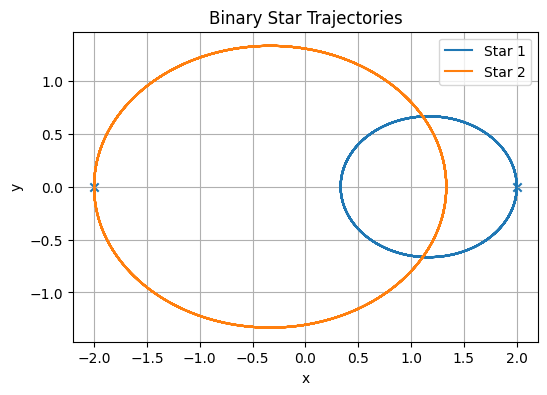

In [49]:
x1_vals = sol.y[0]
y1_vals = sol.y[1]
x2_vals = sol.y[4]
y2_vals = sol.y[5]

plt.figure(figsize=(6,6))
plt.plot(x1_vals, y1_vals, label="Star 1")
plt.plot(x2_vals, y2_vals, label="Star 2")
plt.scatter([sol.y[0,0], sol.y[4,0]], [sol.y[1,0], sol.y[5,0]], marker='x')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Binary Star Trajectories")
plt.gca().set_aspect('equal', 'box')
plt.grid(True)
plt.show()


#### Phase Diagram

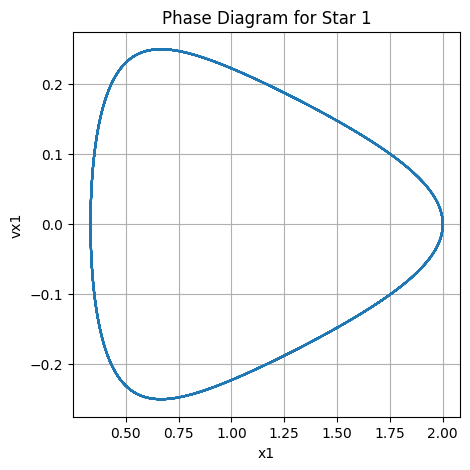

In [50]:
plt.figure(figsize=(5,5))
plt.plot(x1_vals, sol.y[2])  # x vs vx
plt.xlabel("x1")
plt.ylabel("vx1")
plt.title("Phase Diagram for Star 1")
plt.grid(True)
plt.show()


    The phase diagram of 𝑥1 vs vx1 shows:

    The motion of the star is periodic and stable. 

    The orbit repeats over time and that the system remains in closed loop (bounded).

#### Implementing the midpoint method

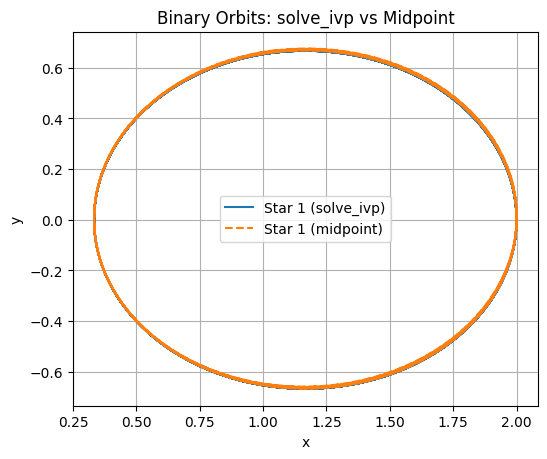

In [51]:
def midpoint_method(system, y0, t_span, dt):
    """
    Took help from GenAI to write this function
    Midpoint method for solving dy/dt = f(t,y)

    system : StarSystem object
    y0     : initial state vector
    t_span : (t_start, t_end)
    dt     : timestep
    """

    t_start, t_end = t_span
    t_vals = [t_start]
    y_vals = [np.array(y0, dtype=float)]

    t = t_start
    y = np.array(y0, dtype=float)

    while t < t_end:

        k1 = np.array(system.ode_rhs(t, y))
        k2 = np.array(system.ode_rhs(t + dt/2, y + dt*k1/2))

        y = y + dt * k2
        t = t + dt

        t_vals.append(t)
        y_vals.append(y.copy())

    return np.array(t_vals), np.array(y_vals).T

# Compare midpoint method with solve_ivp

dt = 0.04
t_mid, y_mid = midpoint_method(binary, y0, t_span, dt)

x1_vals_mid = y_mid[0]
y1_vals_mid = y_mid[1]
x2_vals_mid = y_mid[4]
y2_vals_mid = y_mid[5]

plt.figure(figsize=(6,6))
plt.plot(x1_vals, y1_vals, label="Star 1 (solve_ivp)")
plt.plot(x1_vals_mid, y1_vals_mid, "--", label="Star 1 (midpoint)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Binary Orbits: solve_ivp vs Midpoint")
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', 'box')
plt.show()



#### Convergence Test

In [52]:
# Took help from GenAI to write this code


x2_ref = sol.y[4]
t_ref = sol.t

dt_values = [1.0, 0.5, 0.25, 0.125]
errors = []

for dt in dt_values:

    t_mid, y_mid = midpoint_method(binary, y0, (0, 200), dt)

    # y_mid[4] is x-position of Star 2
    x2_mid = np.interp(t_ref, t_mid, y_mid[4])

    error = np.max(np.abs(x2_mid - x2_ref))
    errors.append(error)

    print(f"dt = {dt:.3f}  -> max error = {error:.4e}")

# Estimate order of convergence
print("\nObserved convergence order:")
for i in range(1, len(errors)):
    order = np.log(errors[i-1]/errors[i]) / np.log(dt_values[i-1]/dt_values[i])
    print(f"between dt = {dt_values[i-1]} and {dt_values[i]} : {order:.2f}")


dt = 1.000  -> max error = 8.7036e+00
dt = 0.500  -> max error = 4.3195e+00
dt = 0.250  -> max error = 3.5229e+00
dt = 0.125  -> max error = 1.5105e+00

Observed convergence order:
between dt = 1.0 and 0.5 : 1.01
between dt = 0.5 and 0.25 : 0.29
between dt = 0.25 and 0.125 : 1.22


##### Why is midoint method better that Euler's method
1. The midpoint method has second-order accuracy whereas Euler’s method is only first-order. It achieves errors for the same timestep.

2. The midpoint method evaluates the slope at an intermediate point, making it more sensitive to curvature in the trajectory so this makes it more stable for orbital problems where forces change rapidly.

#### The above code was supposed to show

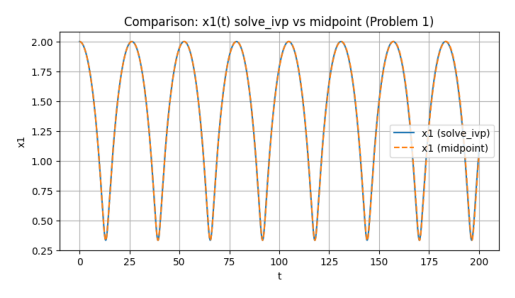

In [53]:
# There was another method for the convergence test which showed the plot below.
# Display image

img = plt.imread('/workspaces/TISC_Coursework/output.png')
plt.imshow(img)
plt.axis('off')
plt.show()

### Modified Star System

In [54]:
class ModifiedStarSystem(StarSystem):
    
    def __init__(self, stars, lambda_param=0.1):
        super().__init__(stars)
        assert lambda_param >= 0.0, "lambda must be non-negative"
        self.lambda_param = float(lambda_param)

    def ode_rhs(self, t, y):
        # update positions and velocities in Star objects from y
        N = self.N
        for i in range(N):
            base = 4*i
            self.stars[i].x  = float(y[base + 0])
            self.stars[i].y  = float(y[base + 1])
            self.stars[i].vx = float(y[base + 2])
            self.stars[i].vy = float(y[base + 3])

        dydt = np.zeros_like(y, dtype=float)
        for i in range(N):
            base_i = 4*i
            dydt[base_i + 0] = self.stars[i].vx
            dydt[base_i + 1] = self.stars[i].vy

        for i in range(N):
            axi = 0.0; ayi = 0.0
            xi = self.stars[i].x; yi = self.stars[i].y
            vxi = self.stars[i].vx; vyi = self.stars[i].vy
            for j in range(N):
                if j == i:
                    continue
                xj = self.stars[j].x; yj = self.stars[j].y
                vxj = self.stars[j].vx; vyj = self.stars[j].vy
                dx = xj - xi; dy = yj - yi
                r2 = dx*dx + dy*dy
                if r2 == 0.0:
                    r2 = 1e-12
                r = np.sqrt(r2)
                # compute L_ij
                Lij = (vyj - vyi)*dx - (vxj - vxi)*dy
                factor = 1.0 + 3.0 * (self.lambda_param**2) * (Lij**2) / r2
                a_mag = factor * (self.stars[j].mass / r2)
                axi += a_mag * (dx / r)
                ayi += a_mag * (dy / r)
            base = 4*i
            dydt[base + 2] = axi
            dydt[base + 3] = ayi
        return dydt


### PROBLEM 2 : Triple system (25 marks)
#### 2a) STABLE THREE-BODY SYSTEM

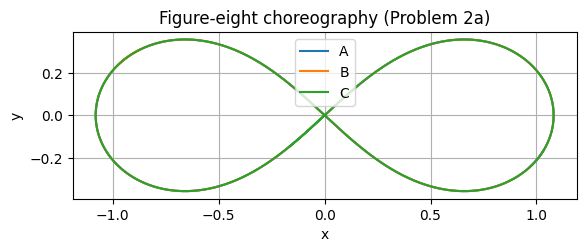

In [55]:
# Initial conditions for figure 8 (Chenciner & Montgomery)
x1_ = 0.97000436; y1_ = -0.24308753
x2_ = -x1_; y2_ = -y1_
x3_ = 0.0; y3_ = 0.0
vx3_ = -0.93240737; vy3_ = -0.86473146
vx1_ = -vx3_/2; vy1_ = -vy3_/2
vx2_ = vx1_; vy2_ = vy1_

# 3 stars A,B and C
A = Star(1.0, x1_, y1_, vx1_, vy1_)
B = Star(1.0, x2_, y2_, vx2_, vy2_)
C = Star(1.0, x3_, y3_, vx3_, vy3_)

three = StarSystem([A, B, C]) # 3 body star system
y0_3 = np.array([A.x, A.y, A.vx, A.vy, B.x, B.y, B.vx, B.vy, C.x, C.y, C.vx, C.vy], dtype=float)

t_span3 = (0.0, 6.5)
t_eval3 = np.linspace(t_span3[0], t_span3[1], 3000)
sol3 = solve_ivp(three.ode_rhs, t_span3, y0_3, t_eval=t_eval3, rtol=1e-9, atol=1e-12)

# plot figure-eight
plt.figure(figsize=(6.5,6))
plt.plot(sol3.y[0], sol3.y[1], label='A')
plt.plot(sol3.y[4], sol3.y[5], label='B')
plt.plot(sol3.y[8], sol3.y[9], label='C')
plt.gca().set_aspect('equal', 'box')
plt.title('Figure-eight choreography (Problem 2a)')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid(True)
plt.show()

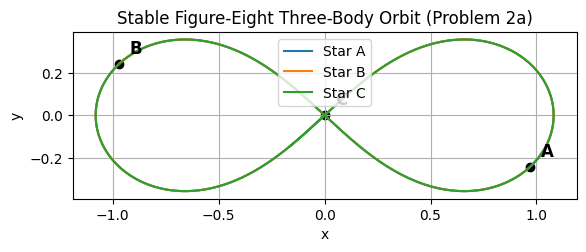

In [56]:
# Plotting the figure-eight orbit
plt.figure(figsize=(6.5,6))

plt.plot(sol3.y[0], sol3.y[1], label='Star A')
plt.plot(sol3.y[4], sol3.y[5], label='Star B')
plt.plot(sol3.y[8], sol3.y[9], label='Star C')

# Mark initial positions of A, B, C
plt.scatter(sol3.y[0,0], sol3.y[1,0], color='black', marker='o')
plt.scatter(sol3.y[4,0], sol3.y[5,0], color='black', marker='o')
plt.scatter(sol3.y[8,0], sol3.y[9,0], color='black', marker='o')

# Label the points on the plot
plt.text(sol3.y[0,0] + 0.05, sol3.y[1,0] + 0.05, "A", fontsize=12, weight='bold')
plt.text(sol3.y[4,0] + 0.05, sol3.y[5,0] + 0.05, "B", fontsize=12, weight='bold')
plt.text(sol3.y[8,0] + 0.05, sol3.y[9,0] + 0.05, "C", fontsize=12, weight='bold')

plt.gca().set_aspect('equal', 'box')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Stable Figure-Eight Three-Body Orbit (Problem 2a)")
plt.legend()
plt.grid(True)
plt.show()


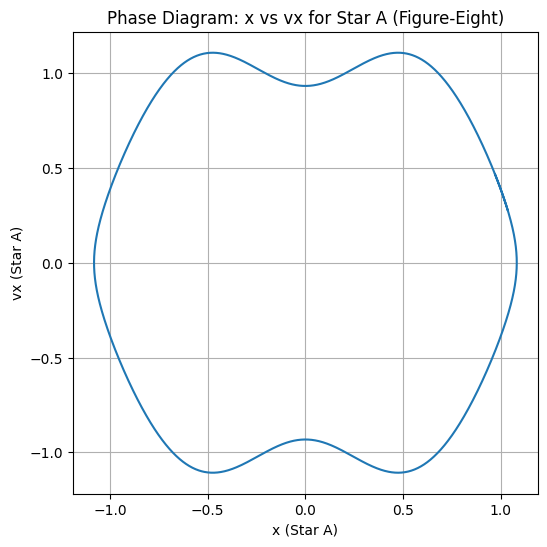

In [57]:
plt.figure(figsize=(6,6))

plt.plot(sol3.y[0], sol3.y[2])

plt.xlabel("x (Star A)")
plt.ylabel("vx (Star A)")
plt.title("Phase Diagram: x vs vx for Star A (Figure-Eight)")
plt.grid(True)
plt.show()

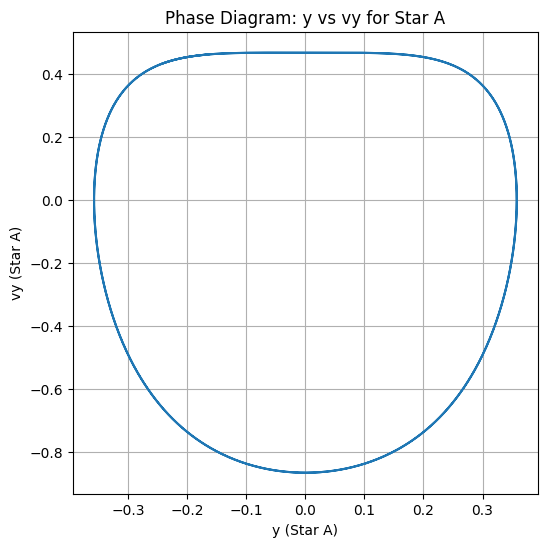

In [58]:
plt.figure(figsize=(6,6))
plt.plot(sol3.y[1], sol3.y[3])
plt.xlabel("y (Star A)")
plt.ylabel("vy (Star A)")
plt.title("Phase Diagram: y vs vy for Star A")
plt.grid(True)
plt.show()


#### Convergance Test

In [59]:
# Convergence test for midpoint method on figure-eight orbit

t_ref = sol3.t
y1_ref = sol3.y[1]   # y-position of first star

dt_values = [0.2, 0.1, 0.05, 0.025]
errors = []

for dt in dt_values:
    t_mid, y_mid = midpoint_method(three.ode_rhs, t_span3, y0_3, dt)

    # Extract y of first star (index 1) and interpolate onto reference times
    y1_mid_interp = np.interp(t_ref, t_mid, y_mid[:, 1])

    # Maximum absolute error
    err = np.max(np.abs(y1_mid_interp - y1_ref))
    errors.append(err)

    print(f"dt = {dt:.4f}, max error = {err:.3e}")

# Estimate order of convergence
print("\nObserved convergence orders:")
for i in range(1, len(errors)):
    order = np.log(errors[i-1] / errors[i]) / np.log(dt_values[i-1] / dt_values[i])
    print(f"Between dt={dt_values[i-1]} and {dt_values[i]}: order ≈ {order:.2f}")



ValueError: too many values to unpack (expected 2)

It is not working because in midpoint method I returned Transpose.

#### 2b) A caotic 3 body problem

In [ ]:
# Chaotic initial conditions
m = 1.0

star1 = Star(m, -2.0, 0.0,  0.0,  0.3)
star2 = Star(m,  2.0, 0.0,  0.0, -0.3)
star3 = Star(m,  0.0, 1.5,  0.25, 0.0)

chaotic_system = StarSystem([star1, star2, star3])

y0_chaotic = np.array([
    star1.x, star1.y, star1.vx, star1.vy,
    star2.x, star2.y, star2.vx, star2.vy,
    star3.x, star3.y, star3.vx, star3.vy
], dtype=float)

t_span_chaotic = (0, 120)
t_eval_chaotic = np.linspace(0, 120, 4000)

sol_chaotic = solve_ivp(
    chaotic_system.ode_rhs,
    t_span_chaotic,
    y0_chaotic,
    t_eval=t_eval_chaotic,
    rtol=1e-9,
    atol=1e-12
)


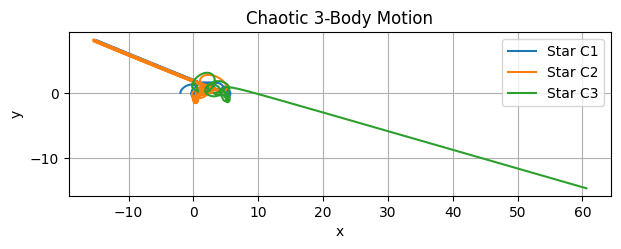

In [ ]:
# Trajectory plot
plt.figure(figsize=(7,6))

plt.plot(sol_chaotic.y[0], sol_chaotic.y[1], label='Star C1')
plt.plot(sol_chaotic.y[4], sol_chaotic.y[5], label='Star C2')
plt.plot(sol_chaotic.y[8], sol_chaotic.y[9], label='Star C3')

plt.gca().set_aspect('equal', 'box')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Chaotic 3-Body Motion")
plt.legend()
plt.grid(True)
plt.show()

#### Better view of chaotic system

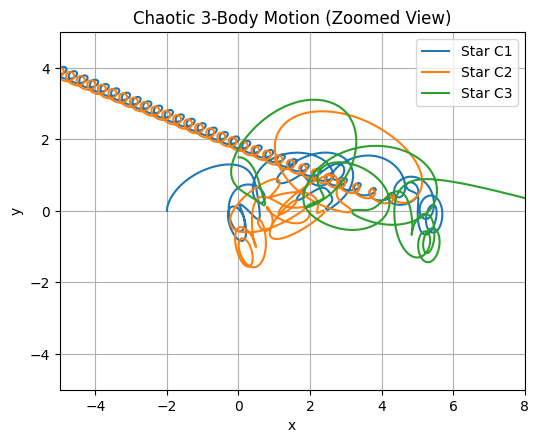

In [ ]:
plt.figure(figsize=(6, 6))

plt.plot(sol_chaotic.y[0], sol_chaotic.y[1], label='Star C1')
plt.plot(sol_chaotic.y[4], sol_chaotic.y[5], label='Star C2')
plt.plot(sol_chaotic.y[8], sol_chaotic.y[9], label='Star C3')

plt.xlim(-5, 8)
plt.ylim(-5, 5)

plt.gca().set_aspect('equal', 'box')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Chaotic 3-Body Motion (Zoomed View)")
plt.legend()
plt.grid(True)
plt.show()


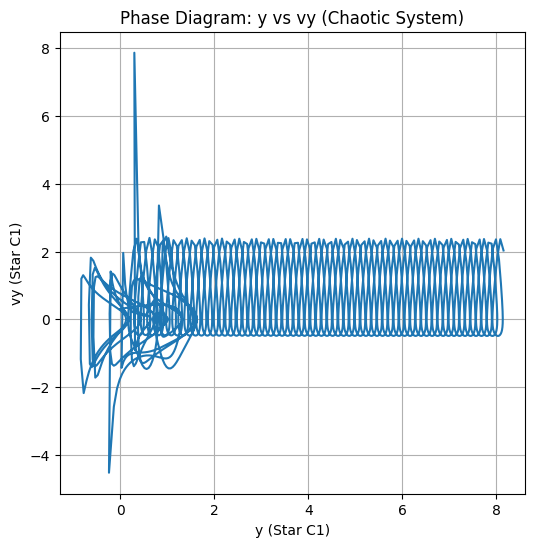

In [ ]:
# Phase diagram for Star C1
plt.figure(figsize=(6,6))

plt.plot(sol_chaotic.y[1], sol_chaotic.y[3])

plt.xlabel("y (Star C1)")
plt.ylabel("vy (Star C1)")
plt.title("Phase Diagram: y vs vy (Chaotic System)")
plt.grid(True)
plt.show()


#### Explain how and why the phase plot differs from the stable system above.

The stable system phase plot forms a closed loop, showing periodic and bounded motion. The chaotic system, however, fills a scattered region of phase space, indicating sensitivity to initial conditions and the absence of repeating trajectories. This irregular structure reflects the unpredictable nature of chaotic gravitational interactions between the stars.

### Problem 3 : Modifications to gravity

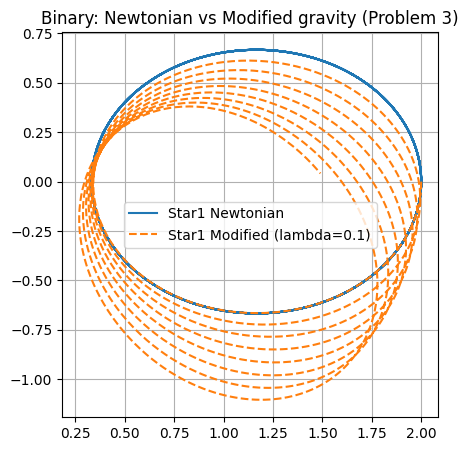

In [ ]:
# Creating fresh stars for the binary modified case
s1m = Star(M1, 2.0, 0.0, 0.0, -0.1)
s2m = Star(M2, -2.0, 0.0, 0.0, -(M1 * -0.1) / M2)
mod_bin = ModifiedStarSystem([s1m, s2m], lambda_param=0.1)
y0_mod = np.array([s1m.x, s1m.y, s1m.vx, s1m.vy, s2m.x, s2m.y, s2m.vx, s2m.vy], dtype=float)
sol_mod = solve_ivp(mod_bin.ode_rhs, (t0, tf), y0_mod, t_eval=np.linspace(t0, tf, 2000), rtol=1e-9, atol=1e-12)

# Compare Newtonian vs modified (plot star1)
plt.figure(figsize=(7,5))
plt.plot(sol.y[0], sol.y[1], label='Star1 Newtonian')
plt.plot(sol_mod.y[0], sol_mod.y[1], '--', label='Star1 Modified (lambda=0.1)')
plt.title('Binary: Newtonian vs Modified gravity (Problem 3)')
plt.gca().set_aspect('equal', 'box')
plt.legend(); plt.grid(True)
plt.show()

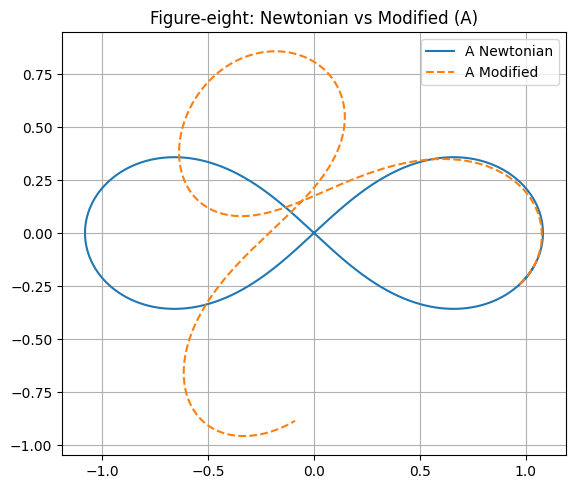

In [ ]:
# Figure-eight under modified gravity (brief compare for star A)
A2 = Star(1.0, x1_, y1_, vx1_, vy1_)
B2 = Star(1.0, x2_, y2_, vx2_, vy2_)
C2 = Star(1.0, x3_, y3_, vx3_, vy3_)
mod_three = ModifiedStarSystem([A2, B2, C2], lambda_param=0.1)
y0_3_mod = np.array([A2.x, A2.y, A2.vx, A2.vy, B2.x, B2.y, B2.vx, B2.vy, C2.x, C2.y, C2.vx, C2.vy], dtype=float)
sol3_mod = solve_ivp(mod_three.ode_rhs, t_span3, y0_3_mod, t_eval=t_eval3, rtol=1e-9, atol=1e-12)

plt.figure(figsize=(6.5,6))
plt.plot(sol3.y[0], sol3.y[1], label='A Newtonian')
plt.plot(sol3_mod.y[0], sol3_mod.y[1], '--', label='A Modified')
plt.title('Figure-eight: Newtonian vs Modified (A)')
plt.gca().set_aspect('equal', 'box')
plt.legend(); plt.grid(True)
plt.show()

#### Why Mercury is better than Jupiter for detecting the modification

Mercury is much closer to the Sun, so it experiences a much stronger gravitational field. In Albert’s modified equation, the extra term becomes more important when the distance between objects is small. This means the correction has a noticeable effect on Mercury’s orbit, slightly changing its motion compared to standard Newtonian predictions.

Although Jupiter is more massive, it is much farther away from the Sun. At large distances, the modification becomes very weak and is effectively hidden by the normal gravitational behaviour. As a result, any deviation from Newtonian gravity is much harder to observe in Jupiter’s motion.

Therefore, Mercury’s close orbit makes it far more sensitive for detecting small changes in gravitational behaviour, which is why Albert should study Mercury rather than Jupiter.